### __Main imports__

In [47]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### __Reading Data: CSV file - Transactional data__

In [48]:
path = "BI_Class_2_eda.csv"
df = pd.read_csv(path)
df.head(10) #df.tail()

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,Clothing,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,Clothing,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,Home,united states,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01 03:00:00,32.0,Clothing,Canada,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01 04:00:00,60.0,Toys,U.S.A.,3,108.073620,66.607272,2.194199,327.554394
5,5005,2024-01-01 05:00:00,25.0,Toys,UK,7,92.066465,7.685147,3.996392,645.631656
6,5006,2024-01-01 06:00:00,78.0,Clothing,Germany,10,61.238242,6.416475,2.123129,612.471490
7,5007,2024-01-01 07:00:00,38.0,Toys,Canada,8,321.850822,17.293285,4.401106,2587.686906
8,5008,2024-01-01 08:00:00,56.0,Toys,UK,6,356.173106,28.908121,2.351358,2131.121545
9,5009,2024-01-01 09:00:00,75.0,Elect.,Canada,10,25.477211,45.807167,1.871478,259.565999


### __Exploratoy Data Analysis (EDA)__ 

#### __Let's check the dataframe features__

In [49]:
#DESCRIBE
df.describe()
#df['categoricall_feature'].describe()

,Transaction_ID,Customer_Age,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
count,2550.000000,2424.000000,2550.000000,2550.000000,2550.000000,2475.000000,2550.000000
mean,6225.480392,49.094884,5.545882,315.166411,52.028912,3.049203,1411.328312
std,734.631632,17.877030,2.882295,702.822872,27.756064,1.000743,1153.869290
min,5000.000000,18.000000,1.000000,10.005701,5.114343,1.000000,-10.294671
25%,5587.250000,34.000000,3.000000,132.373066,27.511696,2.266439,448.038896
50%,6224.500000,49.000000,6.000000,258.960575,51.324563,3.032429,1086.333938
75%,6861.750000,65.000000,8.000000,379.875368,76.712596,3.835179,2105.937489
max,7499.000000,79.000000,10.000000,11478.781639,99.890259,5.000000,4992.820153


In [50]:
#INFO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    2550 non-null   int64  
 1   Date              2550 non-null   object 
 2   Customer_Age      2424 non-null   float64
 3   Product_Category  2550 non-null   object 
 4   Country           2550 non-null   object 
 5   Units_Sold        2550 non-null   int64  
 6   Unit_Price        2550 non-null   float64
 7   Shipping_Cost     2550 non-null   float64
 8   Rating            2475 non-null   float64
 9   Total_Revenue     2550 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 199.3+ KB


In [ ]:
#COLUMNS LIST
df.columns

['Transaction_ID',
 'Date',
 'Customer_Age',
 'Product_Category',
 'Country',
 'Units_Sold',
 'Unit_Price',
 'Shipping_Cost',
 'Rating',
 'Total_Revenue']

In [52]:
#DATAFRAME SHAPE: ROWS - COLUMNS
df.shape

(2550, 10)

#### __Let's apply some counting to our categorical features__

In [53]:
df['Product_Category'].value_counts().reset_index().sort_values(by ="count", ascending = False)

,Product_Category,count
0,Clothing,535
1,Books,517
2,Toys,485
3,Home,478
4,Elect.,155
5,ELECTRONICS,132
6,electronics,126
7,Electronic,122


In [54]:
df['Product_Category'].unique()

array(['Clothing', 'Home', 'Toys', ' Elect. ', 'Books', 'Electronic',
       'ELECTRONICS', 'electronics'], dtype=object)

In [55]:
df['Product_Category'].nunique()

8

### __Analyzing + Solving Data issues__

* __Nan Values__
* __Standarize categorical features__
* __Duplicated rows__


In [56]:
#NaN Summary
df.isna().sum().sort_values(ascending=False)

Customer_Age        126
Rating               75
Transaction_ID        0
Date                  0
Product_Category      0
Country               0
Units_Sold            0
Unit_Price            0
Shipping_Cost         0
Total_Revenue         0
dtype: int64

In [57]:
mean_customer_age = df['Customer_Age'].mean()
mean_customer_rating = df['Rating'].mean()

df['Customer_Age'] = df['Customer_Age'].fillna(mean_customer_age)
df['Rating'] = df['Rating'].fillna(mean_customer_rating)

In [58]:
df.isna().sum()

Transaction_ID      0
Date                0
Customer_Age        0
Product_Category    0
Country             0
Units_Sold          0
Unit_Price          0
Shipping_Cost       0
Rating              0
Total_Revenue       0
dtype: int64

In [59]:
#Standarize Categorical Features
df['Product_Category'].unique()

array(['Clothing', 'Home', 'Toys', ' Elect. ', 'Books', 'Electronic',
       'ELECTRONICS', 'electronics'], dtype=object)

In [60]:
#STANDARIZING 
df['Product_Category'] = df['Product_Category'].str.strip()
df['Product_Category'] = df['Product_Category'].replace('Elect.', 'Electronics')
df['Product_Category'] = df['Product_Category'].replace('Electronic', 'Electronics')
df['Product_Category'] = df['Product_Category'].str.upper()

In [61]:
df['Product_Category'].unique()

array(['CLOTHING', 'HOME', 'TOYS', 'ELECTRONICS', 'BOOKS'], dtype=object)

In [62]:
#DUPLICATE VALUES
df[df.duplicated(keep = False)].sort_values(by = 'Transaction_ID').head(6)

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01 00:00:00,56.0,CLOTHING,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
2500,5000,2024-01-01 00:00:00,56.0,CLOTHING,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01 01:00:00,69.0,CLOTHING,UK,2,288.095016,68.667619,2.867071,582.704472
2501,5001,2024-01-01 01:00:00,69.0,CLOTHING,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01 02:00:00,46.0,HOME,united states,1,347.837835,21.641612,3.171993,337.542782
2502,5002,2024-01-01 02:00:00,46.0,HOME,united states,1,347.837835,21.641612,3.171993,337.542782


In [63]:
#DELETING DUPLICATES
df.drop_duplicates(keep = 'first').shape

(2500, 10)

### __Basic statiscal summary__

In [64]:
def summary_numerical_feature(data,numerical_feature):
    min        =  data[numerical_feature].min() 
    max        =  data[numerical_feature].max() 
    mean       =  data[numerical_feature].mean() 
    median     =  data[numerical_feature].median()  
    std        =  data[numerical_feature].std()
    variance   =  data[numerical_feature].var() 
    Q1         =  data[numerical_feature].quantile(0.25)
    Q2         =  data[numerical_feature].quantile(0.5)
    Q3         =  data[numerical_feature].quantile(0.75)

    print(f"STATISTICAL SUMARY - NUMERICAL FEATURE - {numerical_feature}")
    print("--------------------------------------------")
    print(f"- min      : {min}")
    print(f"- max      : {max}")
    print(f"- range    : {max -min}") 
    print(f"- mean     : {mean}")
    print(f"- median   : {median}")
    print(f"- std      : {std}")
    print(f"- variance : {variance}")
    print(f"- Q1       : {Q1}")
    print(f"- Q2       : {Q2}")
    print(f"- Q3       : {Q3}")
    print(f"- IQR      : {Q3-Q1}") 



summary_numerical_feature(data = df, numerical_feature = 'Total_Revenue')


STATISTICAL SUMARY - NUMERICAL FEATURE - Total_Revenue
--------------------------------------------
- min      : -10.29467078899972
- max      : 4992.820152724489
- range    : 5003.114823513489
- mean     : 1411.3283119794978
- median   : 1086.333938418546
- std      : 1153.8692900034384
- variance : 1331414.338413039
- Q1       : 448.0388962197307
- Q2       : 1086.333938418546
- Q3       : 2105.937489245746
- IQR      : 1657.898593026015


### __Let's plot some results__

#### __Histogram__

In [81]:
def plot_histogram(data, numerical_feature):
    plt.figure(figsize = (15,5))
    plt.hist(x = data[numerical_feature], bins = 100, edgecolor = "black", label = "Total Revenue absolute frequency")
    plt.suptitle(f'Histogram/Distribution- {numerical_feature}', fontsize = 20) 
    plt.title(f'Distribución de {numerical_feature}', fontsize = 15, color = "gray", fontweight='bold') 
    
    plt.axvline(data[numerical_feature].mean(), color = 'red', linestyle ="--", label = f"{numerical_feature} mean")
    plt.axvline(data[numerical_feature].median(), color = 'black', linestyle ="--", label = f"{numerical_feature} median")
    plt.legend()
    plt.xlabel(f'{numerical_feature}')
    plt.ylabel(f'{numerical_feature} - Absolute frequency')
    plt.show()

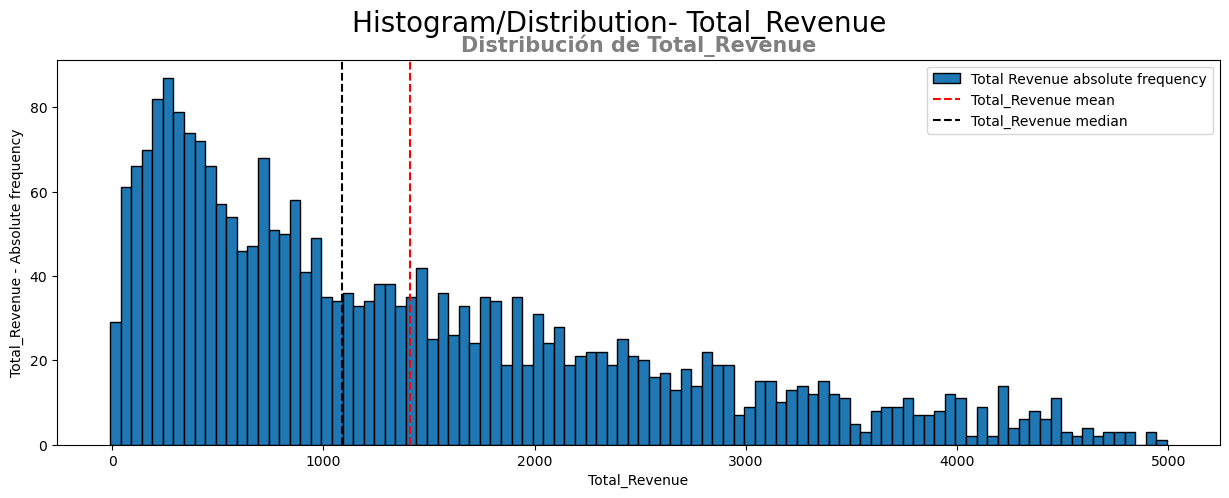

In [82]:
plot_histogram(data = df, numerical_feature = 'Total_Revenue')

#### __Bar plot__


C:\Users\USER\AppData\Local\Temp\ipykernel_8908\1283201993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'Product_Category', y = 'Units_Sold', estimator = 'sum', palette = 'viridis', edgecolor = "black", errorbar = None)


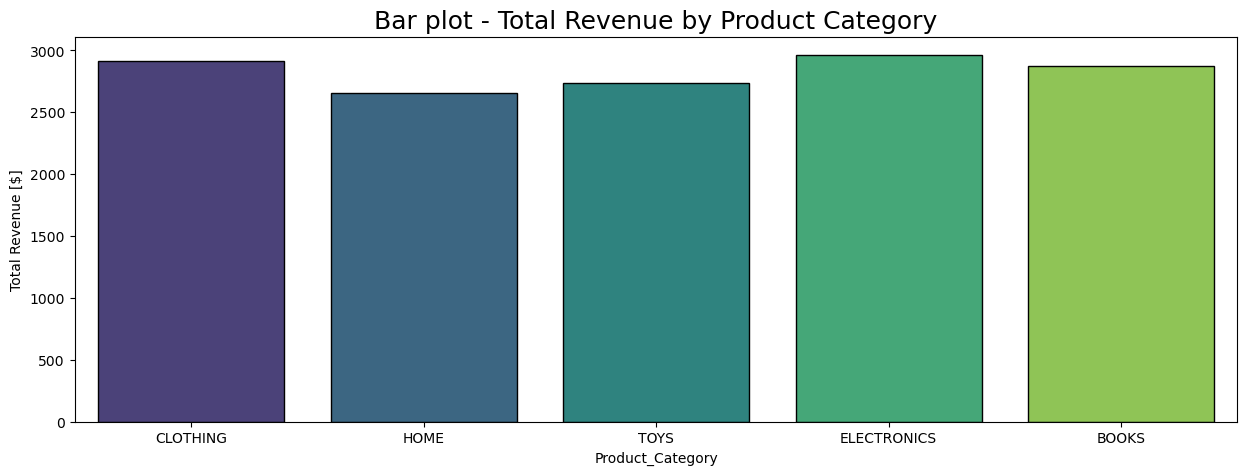

In [67]:
plt.figure(figsize = (15,5))
sns.barplot(data = df, x = 'Product_Category', y = 'Units_Sold', estimator = 'sum', palette = 'viridis', edgecolor = "black", errorbar = None)
plt.xlabel('Product_Category')
plt.ylabel('Total Revenue [$]')
plt.title("Bar plot - Total Revenue by Product Category", fontsize = 18)
plt.show()

### __Box plot__

C:\Users\USER\AppData\Local\Temp\ipykernel_8908\3808188927.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


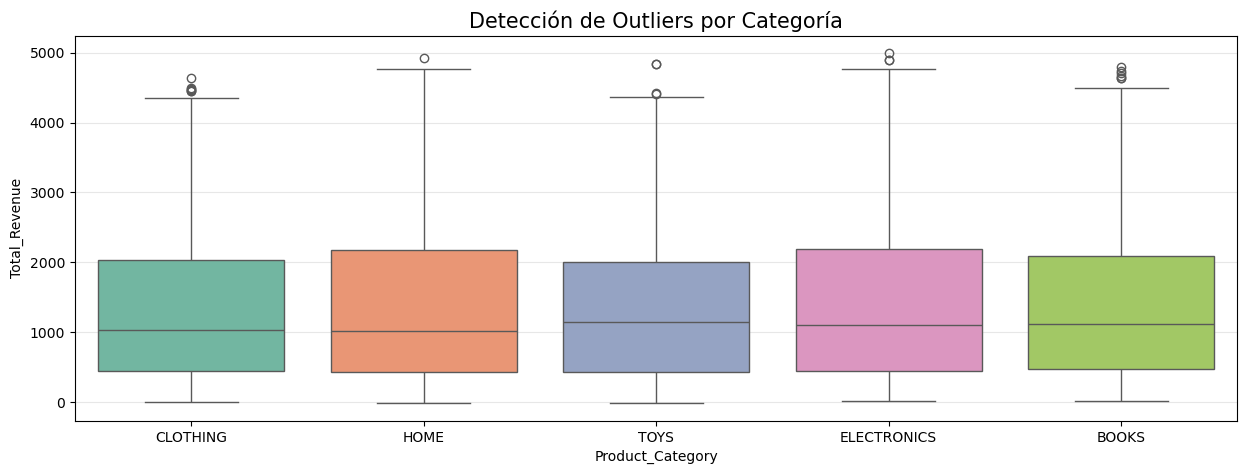

In [68]:
plt.figure(figsize=(15,5))  
sns.boxplot(
    data=df, 
    x='Product_Category', 
    y='Total_Revenue', 
    palette='Set2'
)

plt.title('Detección de Outliers por Categoría', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.show()

#### __Heat map__

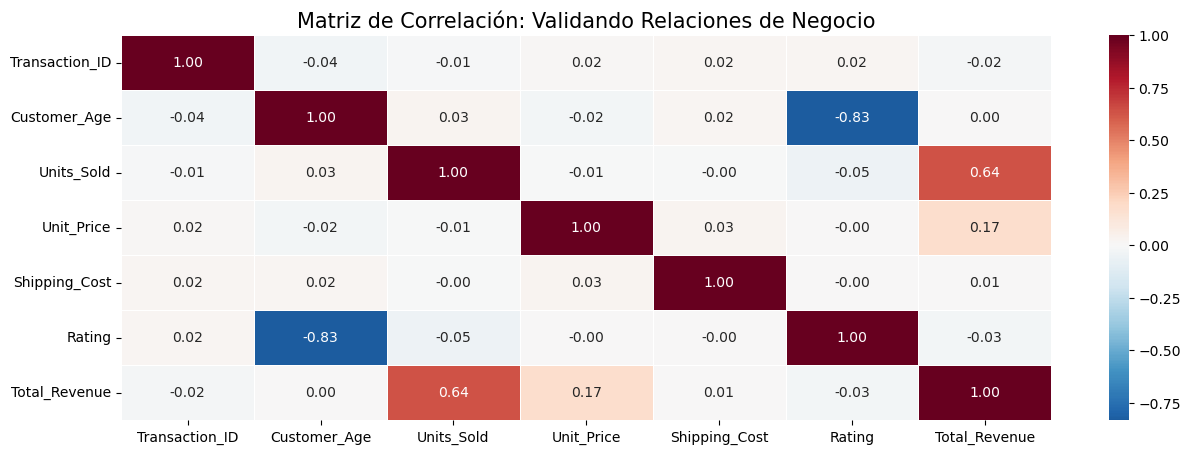

In [69]:
plt.figure(figsize=(15,5))

# Seleccionamos solo columnas numéricas para la correlación
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Dibujamos el mapa de calor
sns.heatmap(
    corr_matrix, 
    annot=True,       # Muestra el número del coeficiente dentro del cuadro
    fmt=".2f",        # Dos decimales
    cmap='RdBu_r',    # Rojo para negativo, Azul para positivo
    center=0,         # El blanco será el 0 (sin correlación)
    linewidths=0.5
)

plt.title('Matriz de Correlación: Validando Relaciones de Negocio', fontsize=15)
plt.show()

In [70]:
df['Date'] = pd.to_datetime(df['Date'])
numeric_columns     = df.select_dtypes(include = [np.number]).columns
categorical_columns = df.select_dtypes(include = ['object']).columns
date_columns        = df.select_dtypes(include = ['datetime64[ns]']).columns

In [71]:
def clean_date(df, date_columns_list, date_format):
    for column in date_columns_list:
        # Convertimos
        df[column] = pd.to_datetime(df[column], format=date_format, errors='coerce')
        # Quitamos zona horaria si la tiene y normalizamos a medianoche
        if df[column].dt.tz is not None:
            df[column] = df[column].dt.tz_localize(None)
        df[column] = df[column].dt.normalize()
    return df

In [72]:
df = clean_date(df,date_columns,date_format='%Y-%m')
df.head()

,Transaction_ID,Date,Customer_Age,Product_Category,Country,Units_Sold,Unit_Price,Shipping_Cost,Rating,Total_Revenue
0,5000,2024-01-01,56.0,CLOTHING,U.S.A.,9,75.030719,96.281280,3.510824,671.612261
1,5001,2024-01-01,69.0,CLOTHING,UK,2,288.095016,68.667619,2.867071,582.704472
2,5002,2024-01-01,46.0,HOME,united states,1,347.837835,21.641612,3.171993,337.542782
3,5003,2024-01-01,32.0,CLOTHING,Canada,8,402.287483,50.009419,4.026504,3205.648837
4,5004,2024-01-01,60.0,TOYS,U.S.A.,3,108.073620,66.607272,2.194199,327.554394
